In [1]:
import pandas as pd

In [2]:
from scipy.stats import pearsonr
import numpy as np

In [3]:
pwd

'/Users/ebruning/code/TRACER-PAWS-NEXRAD-LMA/notebooks'

In [4]:
df=pd.read_csv('./track_count_constmelt_corrigendum.csv')[:-2]

In [5]:
df

,date,zdr_kdp_ltg,zdr_kdp,zdr_ltg,zdr,nothing,kdp,kdp_ltg,ltg,total,...,Conv_Rosenfeld_CCN,LEAR_Rosenfeld_CCN,ARM CCN,TAMU Maritime Aerosol,TAMU Cont Aerosol,TAMU activation,TAMU Maritime CCN,TAMU Continental CCN,NCCN - STG Nov2025,Unnamed: 32
0,2022-06-02,24.0,30.0,1.0,62.0,59.0,0.0,0,0.0,176,...,2330.0,1644.0,703.40180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-06-04,7.0,18.0,3.0,18.0,119.0,0.0,0,0.0,165,...,3302.0,1868.0,2637.62300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-06-17,5.0,1.0,17.0,38.0,58.0,0.0,0,0.0,119,...,806.0,265.0,598.39820,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-06-22,16.0,27.0,2.0,53.0,90.0,0.0,0,0.0,188,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-07-02,25.0,13.0,9.0,65.0,157.0,0.0,0,0.0,269,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,431.502632,NaN
5,2022-07-06,3.0,6.0,0.0,24.0,46.0,0.0,0,0.0,79,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,610.233661,NaN
6,2022-07-12,15.0,6.0,2.0,35.0,152.0,0.0,0,0.0,210,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1054.924561,NaN
7,2022-07-13,6.0,4.0,0.0,26.0,188.0,0.0,0,0.0,224,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,740.445000,NaN
8,2022-07-14,25.0,24.0,1.0,55.0,160.0,0.0,0,0.0,265,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2022-07-28,23.0,12.0,2.0,48.0,75.0,0.0,0,0.0,160,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,661.327698,NaN


In [6]:
%matplotlib widget
import matplotlib.pyplot as plt

<Axes: xlabel='ECAPE', ylabel='NCCN'>

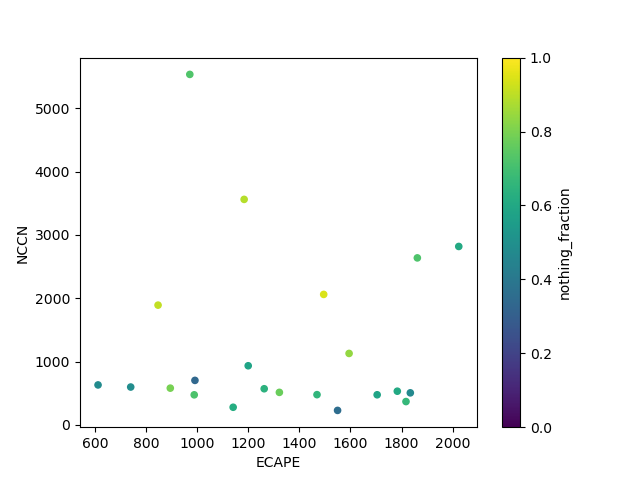

In [7]:
# plt.figure()
df.plot.scatter('ECAPE', 'NCCN', c='nothing_fraction', vmin=0, vmax=1)

<Axes: xlabel='ECAPE', ylabel='NCCN'>

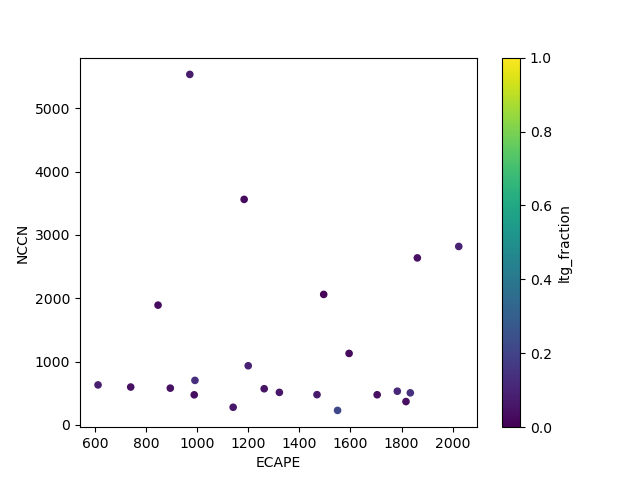

In [8]:
# plt.figure()
df.plot.scatter('ECAPE', 'NCCN', c='ltg_fraction', vmin=0, vmax=1)

In [9]:
import statsmodels.formula.api as sm
# df = pd.DataFrame({"A": [10,20,30,40,50], "B": [20, 30, 10, 40, 50], "C": [32, 234, 23, 23, 42523]})
# result = sm.ols(formula="A ~ B + C", data=df).fit()
finite = df[np.isfinite(df['ECAPE']) & np.isfinite(df['NCCN'])]

print("===== ECAPE - CCN correlation =====")
print("Pearson r, p = ", pearsonr(finite['ECAPE'], finite['NCCN']))
result = sm.ols(formula="ECAPE ~ NCCN", data=finite).fit()
print(result.params)
print(result.summary())
print("")


print("===== Nothing Fraction =====")
result = sm.ols(formula="nothing_fraction ~ ECAPE + NCCN", data=finite).fit()
print(result.params)
print(result.summary())
print("")

print("===== ZDR only Fraction =====")
result = sm.ols(formula="zdr_fraction ~ ECAPE + NCCN", data=finite).fit()
print(result.params)
print(result.summary())
print("")

print("===== ZDR lightning Fraction =====")
result = sm.ols(formula="zdr_ltg_fraction ~ ECAPE + NCCN", data=finite).fit()
print(result.params)
print(result.summary())
print("")

print("===== ZDR KDP Fraction =====")
result = sm.ols(formula="zdr_kdp_fraction ~ ECAPE + NCCN", data=finite).fit()
print(result.params)
print(result.summary())
print("")

print("===== Lightning Fraction =====")
result = sm.ols(formula="ltg_fraction ~ ECAPE + NCCN", data=finite).fit()
print(result.params)
print(result.summary())
print("")

===== ECAPE - CCN correlation =====
Pearson r, p =  PearsonRResult(statistic=-0.014157451061521968, pvalue=0.9501399616398842)
Intercept    1336.579370
NCCN           -0.004324
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                  ECAPE   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.050
Method:                 Least Squares   F-statistic:                  0.004009
Date:                Sun, 21 Dec 2025   Prob (F-statistic):              0.950
Time:                        10:32:17   Log-Likelihood:                -162.94
No. Observations:                  22   AIC:                             329.9
Df Residuals:                      20   BIC:                             332.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 c

In [10]:
def rgbfrac(c):
    return [v/255 for v in c]
frac_vars = [
    ('nothing_fraction', ' \nNothing ',9, (59,117,175), '.'),
    ('zdr_fraction',' \n$Z_{DR}$ ',4, (239,134,54), '+'),
    ('zdr_kdp_fraction','\n$Z_{DR}~~K_{DP}$' ,4, (197,58,50),'x'),
    ('zdr_ltg_fraction','$Z_{DR}$\nLightning',4, (141,105,184),'4'),
    ('ltg_fraction','$Z_{DR}~~K_{DP}$\nLightning' ,9, (213,125,191), 5),
]
physics_vars = [('ECAPE', 'ECAPE (J/kg)', (500,2100)),
        ('NCCN', 'N CCN (cm$^{-3}$)', (0,5700)),
        ('700_rh', '700 hPa RH (%)', (0, 100)),
        ('500_700_rh', '500 to 700 hPa RH (%)', (0, 100)),
        ('specfic_humidity', 'Specific Humidity (kg/kg)', (0.013, 0.018)),
         ]

(14, 33) 14


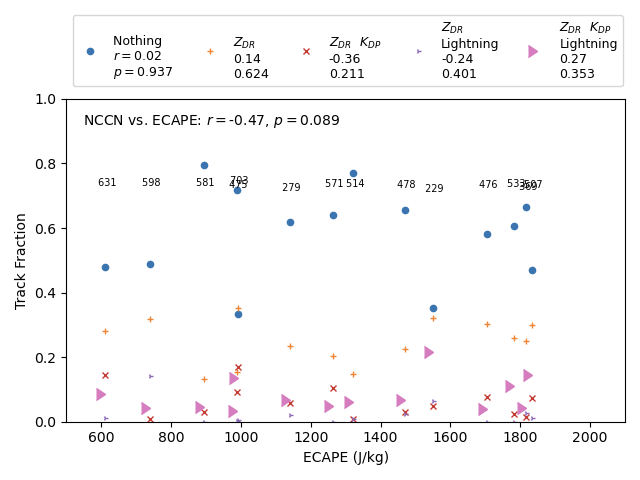

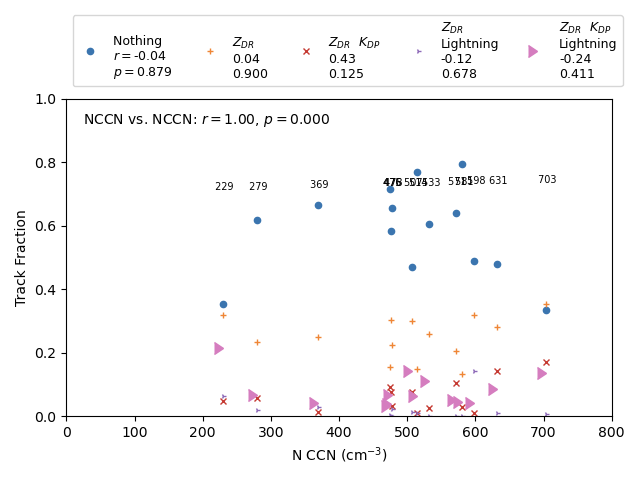

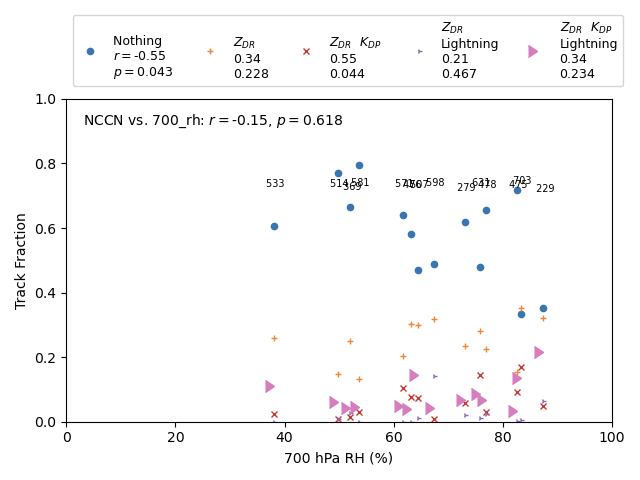

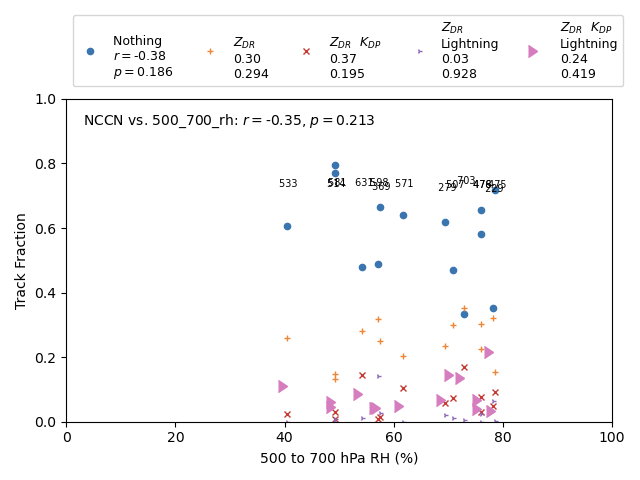

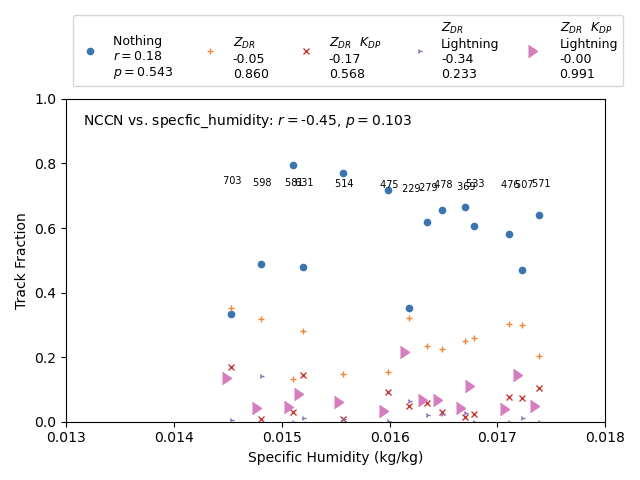

In [15]:
def do_plots(df, label_ccn=False, filetag=''):
    has_ccn = np.isfinite(df['NCCN'])
    print(df.shape, has_ccn.sum())
    for physics, physicslabel, physicsrange in physics_vars:
        label_row=True
        label_ccn_done = False
        fig, ax = plt.subplots(1,1)
        for fv,label, ms,color,marker in frac_vars:
            # finite = df[np.isfinite(df[physics]) & np.isfinite(df[fv])]
            finite = df[has_ccn]
            r, p = pearsonr(finite[physics], finite[fv])
            if label_row:
                rp_label = f'\n$r=${r:0.2f}\n$p=${p:0.3f}'
                label_row=False
            else:
                rp_label = f'\n{r:0.2f}\n{p:0.3f}'
            label_all = label + rp_label
            pl = finite.plot(physics, fv, ax=ax, marker=marker, ms=ms, 
                    color=rgbfrac(color), linewidth=0, label=label_all, legend='top')
            ax.set_xlabel(physicslabel)
            if ('ccnmax' in filetag) and ('CCN' in physicslabel):
                ax.set_xlim(0, int(filetag.replace('ccnmax','')))
            else:
                ax.set_xlim(physicsrange)
                
            ax.set_ylabel('Track Fraction')
            if label_ccn & (~label_ccn_done):
                r, p = pearsonr(finite[physics], finite['NCCN'])
                rp_label = f'NCCN vs. {physics}: $r=${r:0.2f}, $p=${p:0.3f}'
                ax.text(0.03, 0.92, rp_label, transform=ax.transAxes)
                        
                for ci, (txtx, ccnval) in enumerate(zip(finite[physics], finite['NCCN'])):
                    ax.text(txtx, 0.95 + 5e-5*(ccnval-5000), f'{ccnval:4.0f}', horizontalalignment='center', fontsize=7)
                label_ccn_done=True
            pl.legend(loc='lower left', bbox_to_anchor=(0, 1.02), fontsize=9,
                      ncol=len(frac_vars))
            ax.set_ylim(0,1)
            plt.tight_layout()
        fig.savefig(f'{physics}_track_fractions_{filetag}.pdf')

# do_plots(df, label_ccn=True, filetag="revcorrig")
do_plots(df[ df['NCCN'] < 800 ], label_ccn=True, filetag='ccnmax800')

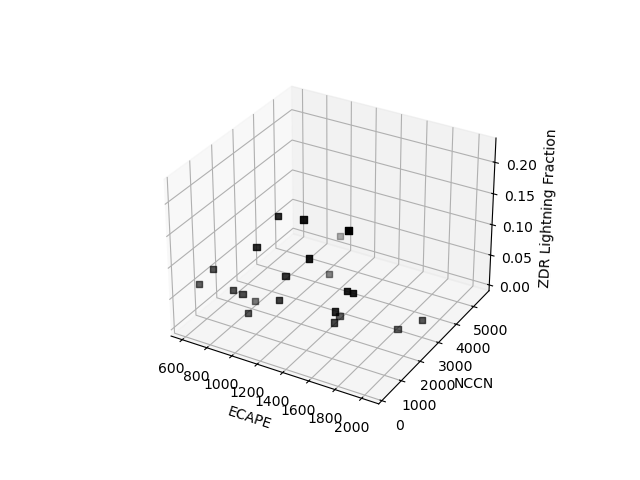

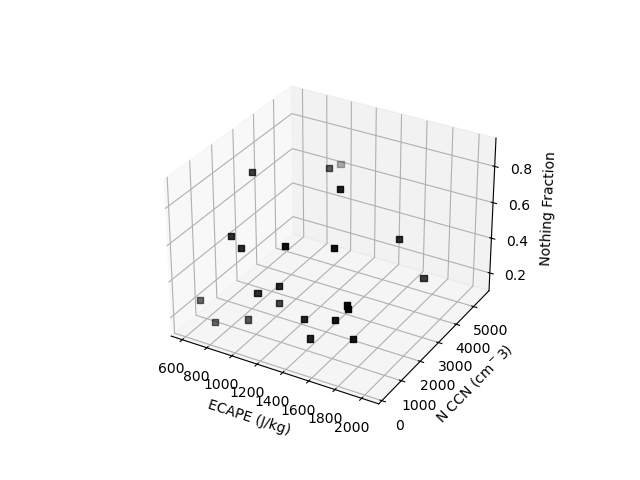

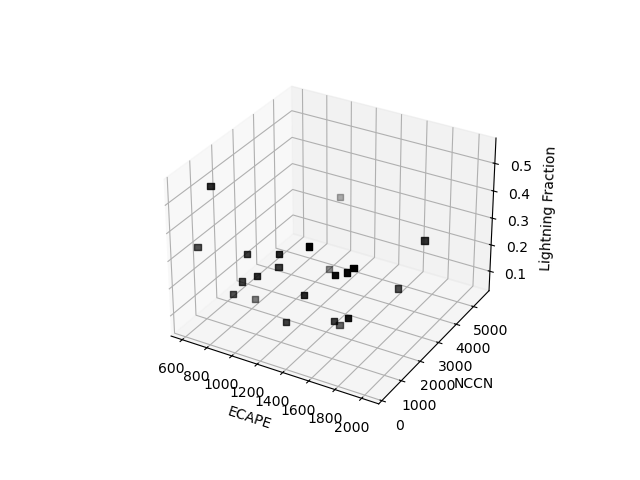

In [13]:
def three_dee(df):
    fig=plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.scatter(df['ECAPE'], df['NCCN'], df['zdr_ltg_fraction'], c='k', marker='s')
    ax.set_xlabel('ECAPE')
    ax.set_ylabel('NCCN')
    ax.set_zlabel('ZDR Lightning Fraction')
    # ax.axis((0,2500, 0,6000,0,.3))

    fig=plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.scatter(df['ECAPE'], df['NCCN'], df['nothing_fraction'], c='k', marker='s')
    ax.set_xlabel('ECAPE (J/kg)')
    ax.set_ylabel('N CCN (cm${^-3}$)')
    ax.set_zlabel('Nothing Fraction')
    # ax.axis((0,2500, 0,6000,0,1))

    fig=plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.scatter(df['ECAPE'], df['NCCN'], df['ltg_fraction'], c='k', marker='s')
    ax.set_xlabel('ECAPE')
    ax.set_ylabel('NCCN')
    ax.set_zlabel('Lightning Fraction')
    # ax.axis((0,2500, 0,6000,0,1))
    
three_dee(df)
# three_dee(df[ df['NCCN'] < 1000 ])